   index                                            product  \
0      1             Garlic Oil - Vegetarian Capsule 500 mg   
1      2                              Water Bottle - Orange   
2      3                     Brass Angle Deep - Plain, No.2   
3      4  Cereal Flip Lid Container/Storage Jar - Assort...   
4      5                 Creme Soft Soap - For Hands & Body   

                 category           sub_category              brand  \
0        Beauty & Hygiene              Hair Care  Sri Sri Ayurveda    
1  Kitchen, Garden & Pets  Storage & Accessories         Mastercook   
2    Cleaning & Household            Pooja Needs                Trm   
3    Cleaning & Household   Bins & Bathroom Ware             Nakoda   
4        Beauty & Hygiene       Bath & Hand Wash              Nivea   

   sale_price  market_price                      type  rating  \
0       220.0         220.0          Hair Oil & Serum     4.1   
1       180.0         180.0    Water & Fridge Bottles     2.3   

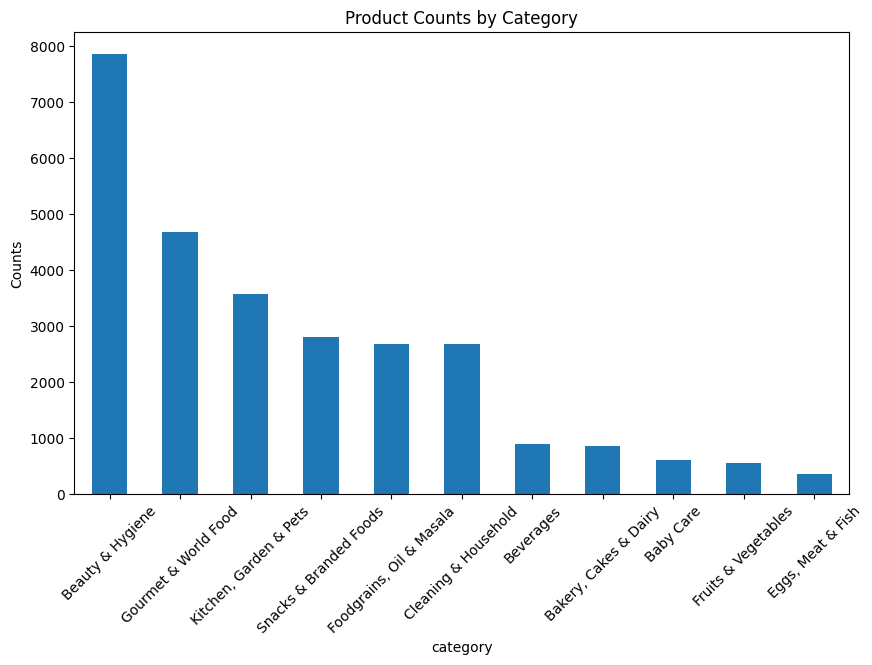

In [11]:
#Category Analysis
import pandas as pd
df = pd.read_csv('/content/drive/MyDrive/BigBasket Products.csv.csv')


# Display first few rows
print(df.head())

# Check for missing values
print(df.isnull().sum())

# Handle missing values if any
df.fillna(value={'Category': 'Unknown', 'Sub Category': 'Unknown', 'Brand': 'Unknown'}, inplace=True)

# Count products by Category
category_counts = df['category'].value_counts()

# Count products by Sub Category
sub_category_counts = df['sub_category'].value_counts()

# Example: Group by Category and Sub Category
category_sub_counts = df.groupby(['category', 'sub_category']).size().reset_index(name='Counts')

# Count products by Brand
brand_counts = df['brand'].value_counts()

# Example: Create price range categories
bins = [0, 500, 1000, 2000, 5000, float('inf')]
labels = ['0-500', '501-1000', '1001-2000', '2001-5000', 'Above 5000']
df['PriceRange'] = pd.cut(df['sale_price'], bins=bins, labels=labels)

# Count products by Price Range
price_range_counts = df['PriceRange'].value_counts()


# Example: Group by Rating and calculate average Sale Price
rating_stats = df.groupby('rating')['sale_price'].mean()

import matplotlib.pyplot as plt

# Example: Plot product counts by Category
category_counts.plot(kind='bar', figsize=(10, 6), title='Product Counts by Category')
plt.xlabel('category')
plt.ylabel('Counts')
plt.xticks(rotation=45)
plt.show()

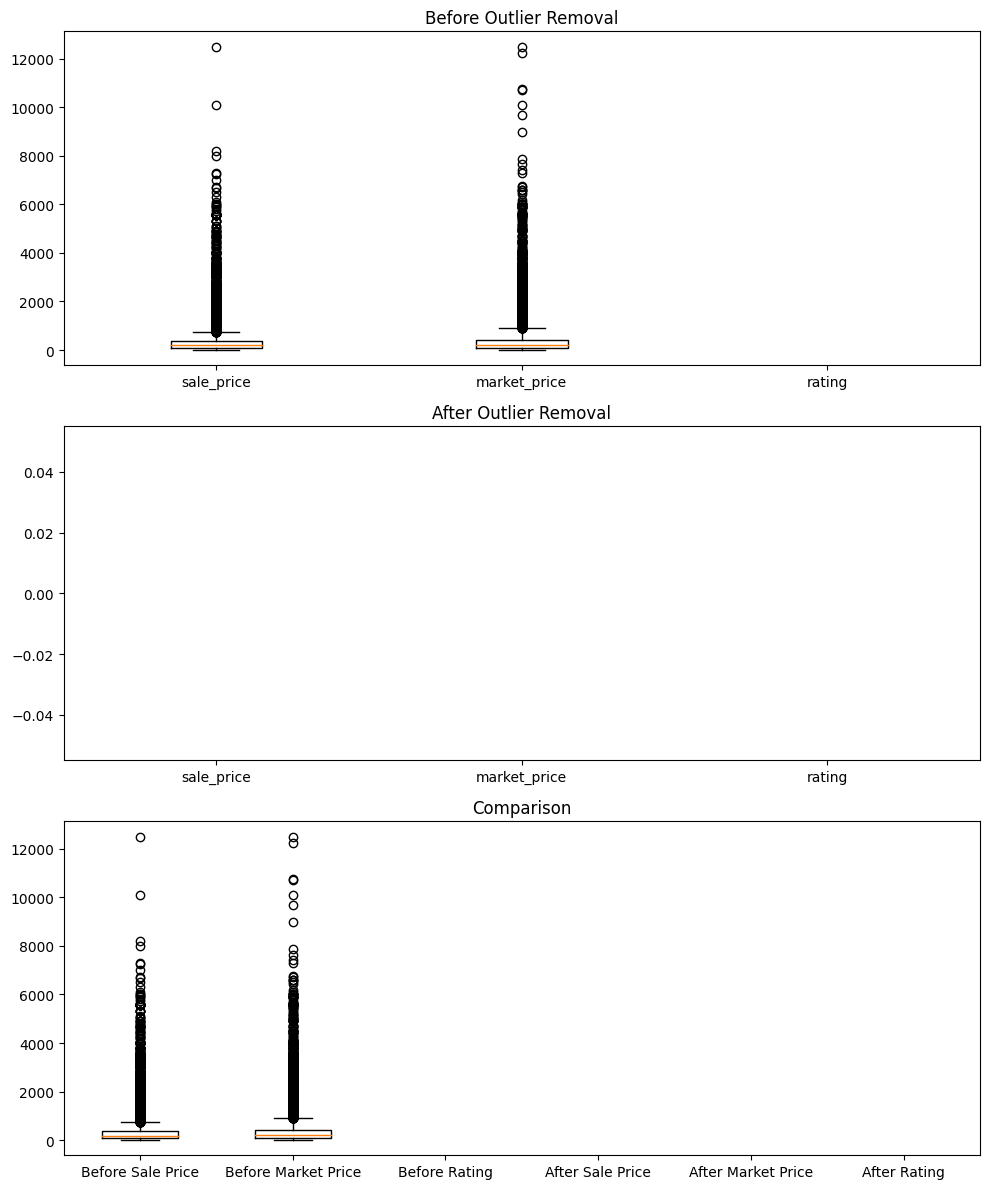

In [15]:
'''Removing Major Ouliers to Optimize data for applying Algorithms, and
Selecting Parameters of Interest'''

import pandas as pd
import matplotlib.pyplot as plt

# Load your dataset
df = pd.read_csv('/content/drive/MyDrive/BigBasket Products.csv.csv')

# Select numeric columns for outlier detection
numeric_columns = ['sale_price', 'market_price', 'rating']

# Convert relevant columns to numeric if necessary
df[numeric_columns] = df[numeric_columns].apply(pd.to_numeric, errors='coerce')

# Calculate quartiles and IQR for numeric columns
Q1 = df[numeric_columns].quantile(0.25)
Q3 = df[numeric_columns].quantile(0.75)
IQR = Q3 - Q1

# Define lower and upper bounds to filter outliers
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Filter out rows with outliers
df_filtered = df[(df[numeric_columns] >= lower_bound) & (df[numeric_columns] <= upper_bound)].dropna()

# Create a figure with subplots for each numeric column
fig, axs = plt.subplots(nrows=3, figsize=(10, 12))

# Box plot before outlier removal
axs[0].boxplot(df[numeric_columns].values, labels=numeric_columns)
axs[0].set_title('Before Outlier Removal')

# Box plot after outlier removal
axs[1].boxplot(df_filtered[numeric_columns].values, labels=numeric_columns)
axs[1].set_title('After Outlier Removal')

# Box plot comparison - Transpose the data to create a list of 1D arrays
axs[2].boxplot([df[col].values for col in numeric_columns] +
               [df_filtered[col].values for col in numeric_columns],
               labels=['Before Sale Price', 'Before Market Price', 'Before Rating',
                       'After Sale Price', 'After Market Price', 'After Rating'])
axs[2].set_title('Comparison')

# Adjust layout and display the plots
plt.tight_layout()
plt.show()

/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:8

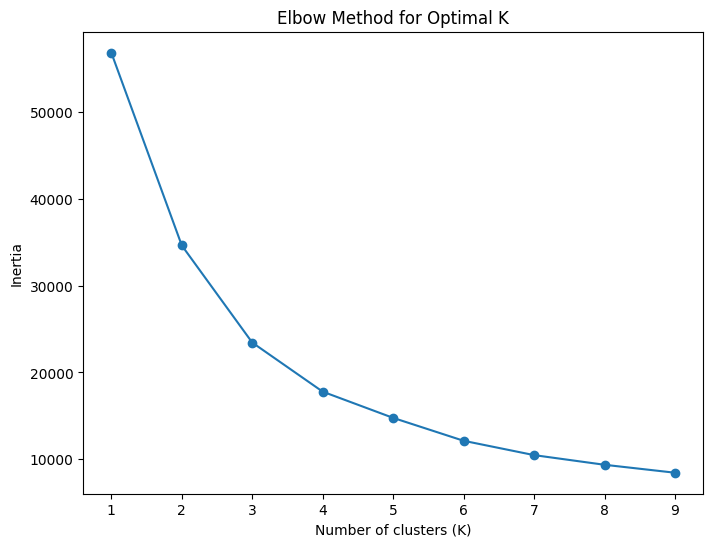

/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


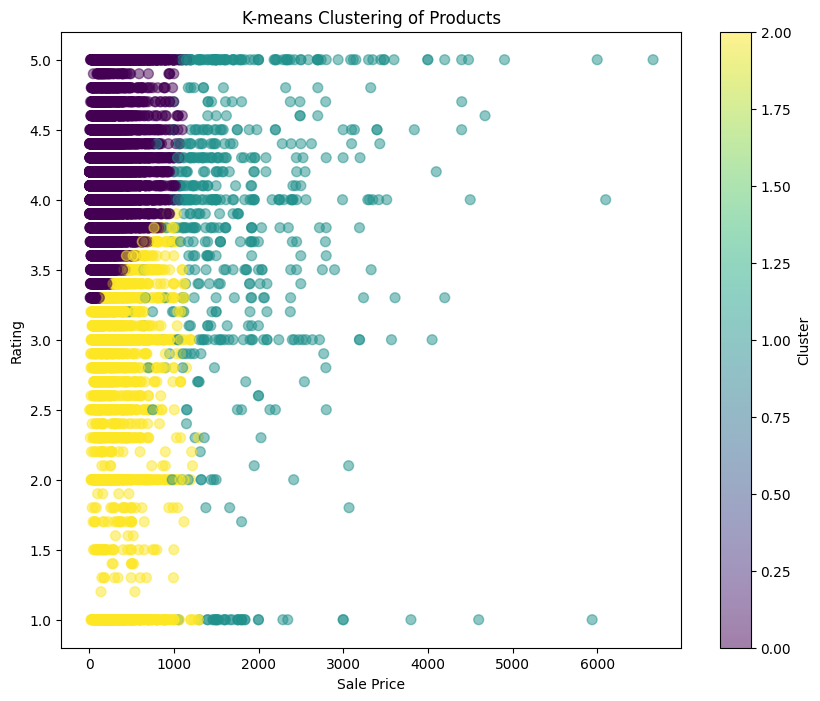

In [17]:
'''Building a Customer Segmentation Model based on Sales Price, Market Price and
Rating by using K-Means Clustering'''
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# Load your dataset
df = pd.read_csv('/content/drive/MyDrive/BigBasket Products.csv.csv')

# Select relevant numeric columns for clustering
numeric_columns = ['sale_price', 'market_price', 'rating']

# Convert relevant columns to numeric if necessary
df[numeric_columns] = df[numeric_columns].apply(pd.to_numeric, errors='coerce')

# Drop rows with missing values
df.dropna(subset=numeric_columns, inplace=True)

# Standardize the numeric columns
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df[numeric_columns])

# Determine the number of clusters (K) using the Elbow method
inertias = []
K_range = range(1, 10)
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(df_scaled)
    inertias.append(kmeans.inertia_)

# Plotting the Elbow method
plt.figure(figsize=(8, 6))
plt.plot(K_range, inertias, marker='o')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of clusters (K)')
plt.ylabel('Inertia')
plt.show()

# Fit K-means clustering model with chosen K
k = 3  # Example: assuming 3 clusters based on Elbow method or domain knowledge
kmeans = KMeans(n_clusters=k, random_state=42)
cluster_labels = kmeans.fit_predict(df_scaled)

# Add cluster labels to the original DataFrame
df['Cluster'] = cluster_labels

# Visualize clusters based on Sale Price and Rating
plt.figure(figsize=(10, 8))
plt.scatter(df['sale_price'], df['rating'], c=df['Cluster'], cmap='viridis', s=50, alpha=0.5)
plt.title('K-means Clustering of Products')
plt.xlabel('Sale Price')
plt.ylabel('Rating')
plt.colorbar(label='Cluster')
plt.show()


/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


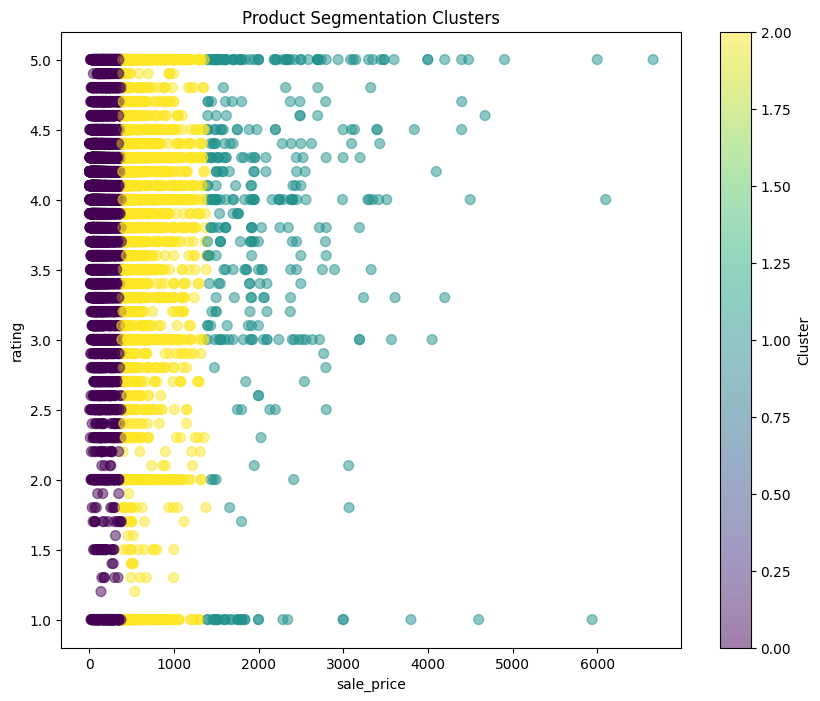

          sale_price    rating
Cluster                       
0         150.058508  3.979401
1        2173.489467  3.776800
2         614.325295  3.788152


In [19]:
'''Segmentation Model Interpretation and Visualization with the help of Scatter
Plot'''
import pandas as pd
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Load your dataset
df = pd.read_csv('/content/drive/MyDrive/BigBasket Products.csv.csv')

# Select relevant columns for segmentation
columns_of_interest = ['sale_price', 'rating']  # Adjust based on your specific columns of interest
data = df[columns_of_interest].copy()

# Handle any missing values or data preprocessing steps
# Drop rows with missing values in the 'data' DataFrame and reset the index
data.dropna(inplace=True)
data.reset_index(drop=True, inplace=True) # Resets the index to match the clustered data

# Define the number of clusters (K)
k = 3  # Example: choose an appropriate number of clusters based on your analysis

# Fit K-means clustering model
kmeans = KMeans(n_clusters=k, random_state=42)
cluster_labels = kmeans.fit_predict(data)

# Add cluster labels to the 'data' DataFrame (not the original 'df')
data['Cluster'] = cluster_labels  # Assign to the DataFrame that was used for clustering

# Example: Scatter plot of clusters based on Sale Price and Rating
plt.figure(figsize=(10, 8))
plt.scatter(data['sale_price'], data['rating'], c=data['Cluster'], cmap='viridis', s=50, alpha=0.5)
plt.title('Product Segmentation Clusters')
plt.xlabel('sale_price')
plt.ylabel('rating')
plt.colorbar(label='Cluster')
plt.show()

# Example: Analyze mean values of each numeric attribute by cluster
cluster_summary = data.groupby('Cluster')[columns_of_interest].mean()
print(cluster_summary)

/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


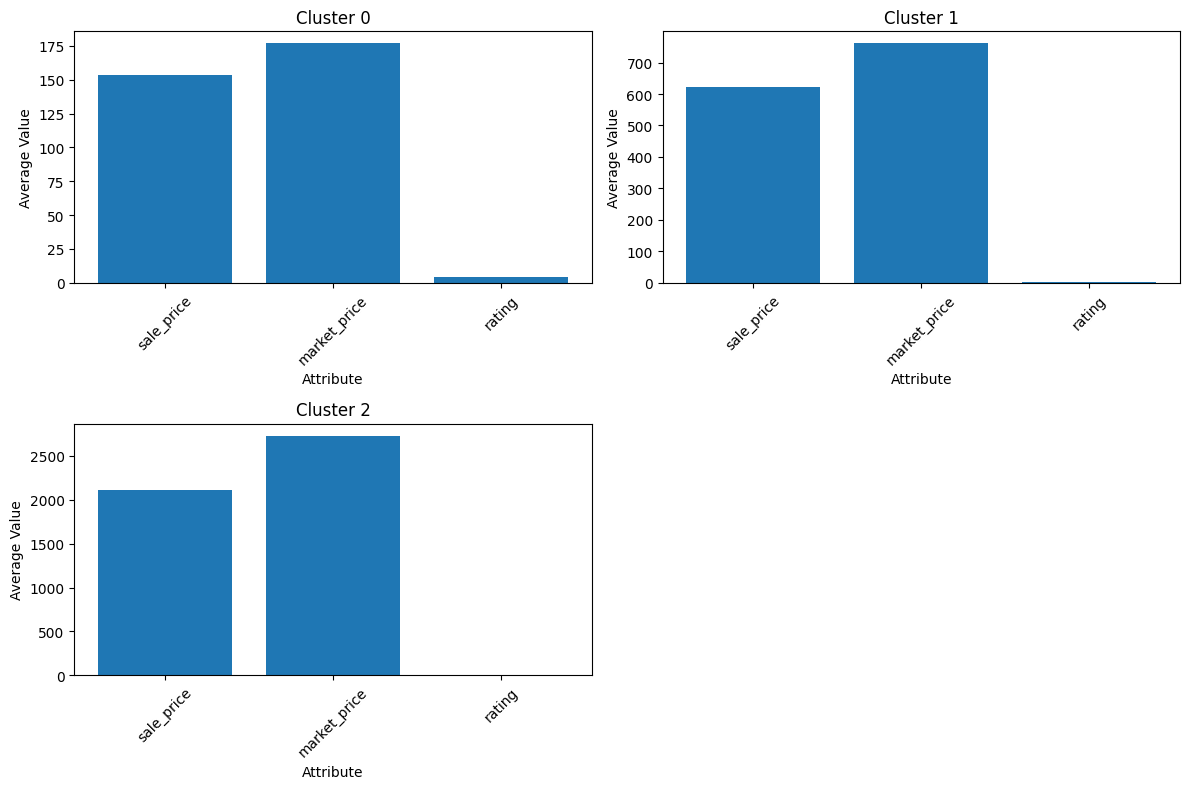

In [21]:
'''Segmentation Model Interpretation and Visualization with the help of Bar
Plot'''
import pandas as pd
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Load your dataset
df = pd.read_csv('/content/drive/MyDrive/BigBasket Products.csv.csv')

# Select relevant columns for segmentation
columns_of_interest = ['sale_price', 'market_price', 'rating']  # Adjust based on your specific columns of interest
data = df[columns_of_interest].copy()

# Handle any missing values or data preprocessing steps
data.dropna(inplace=True)  # Drop rows with missing values if needed

# Define the number of clusters (K)
k = 3  # Example: choose an appropriate number of clusters based on your analysis

# Fit K-means clustering model
kmeans = KMeans(n_clusters=k, random_state=42)
cluster_labels = kmeans.fit_predict(data)

# Add cluster labels to the data DataFrame (not the original df)
data['Cluster'] = cluster_labels # Assign the labels to the DataFrame that was clustered

# Calculate mean values of each numeric attribute by cluster
cluster_summary = data.groupby('Cluster')[columns_of_interest].mean()

# Transpose the summary dataframe for easier plotting
cluster_summary = cluster_summary.transpose()

# Plotting bar graph for each attribute by cluster
plt.figure(figsize=(12, 8))
for i, col in enumerate(cluster_summary.columns):
    plt.subplot(2, 2, i + 1)
    plt.bar(cluster_summary.index, cluster_summary[col])
    plt.title(f'Cluster {col}')
    plt.xlabel('Attribute')
    plt.ylabel('Average Value')
    plt.xticks(rotation=45)
    plt.tight_layout()

plt.show()

/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


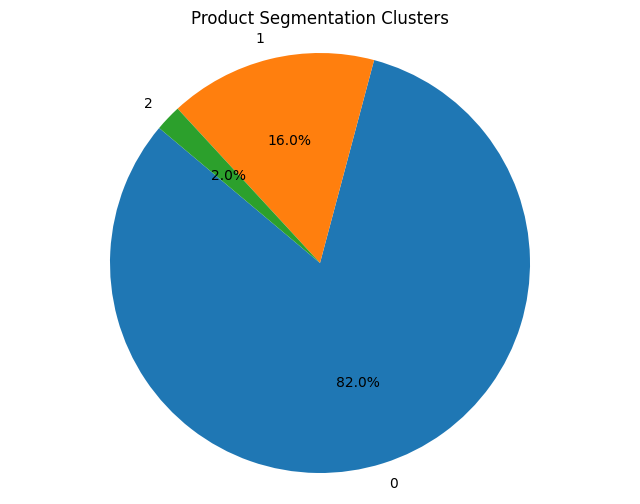

In [23]:
'''Segmentation Model Interpretation and Visualization with the help of Pie
Chart'''
import pandas as pd
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Load your dataset
df = pd.read_csv('/content/drive/MyDrive/BigBasket Products.csv.csv')

# Select relevant columns for segmentation
columns_of_interest = ['sale_price', 'market_price', 'rating']  # Adjust based on your specific columns of interest
data = df[columns_of_interest].copy()

# Handle any missing values or data preprocessing steps
data.dropna(inplace=True)  # Drop rows with missing values if needed

# Define the number of clusters (K)
k = 3  # Example: choose an appropriate number of clusters based on your analysis

# Fit K-means clustering model
kmeans = KMeans(n_clusters=k, random_state=42)
cluster_labels = kmeans.fit_predict(data)

# Add cluster labels to the data DataFrame (not the original df)
data['Cluster'] = cluster_labels # Assign to the DataFrame used for clustering

# Calculate cluster counts
cluster_counts = data['Cluster'].value_counts().sort_index() # Calculate counts from 'data'

# Plotting pie chart for cluster distribution
plt.figure(figsize=(8, 6))
plt.pie(cluster_counts, labels=cluster_counts.index, autopct='%1.1f%%', startangle=140)
plt.title('Product Segmentation Clusters')
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()